# Task 2.1 — Dataset Selection and Preprocessing

**Paper**:
 Efficient Variable Selection in Support Vector Machines via the Alternating Direction Method of Multipliers
(ICML 2011)

---

# Dataset Selection

The reproduction experiment uses the **Breast Cancer Wisconsin dataset**, which is available in the scikit-learn library.

This dataset contains measurements extracted from breast mass images and is commonly used for binary classification tasks.

The dataset contains:

- 569 samples
- 30 numerical features
- Binary labels indicating malignant or benign tumors

This dataset is suitable for testing sparse SVM methods because the feature space is moderately high-dimensional, allowing us to observe how sparsity affects feature selection.

---

# Import Required Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

---

# Load Dataset

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

---

# Dataset Overview

In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 569
Number of features: 30


In [4]:
print(data.DESCR[:500])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (


---

# Convert to DataFrame

In [5]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---

## Feature Correlation Analysis

Since the goal of the paper is variable selection using sparse SVM models, it is useful to examine correlations between features. Highly correlated features may contain redundant information.

Sparse models with L1 regularization can automatically remove such redundant features by assigning zero weights.


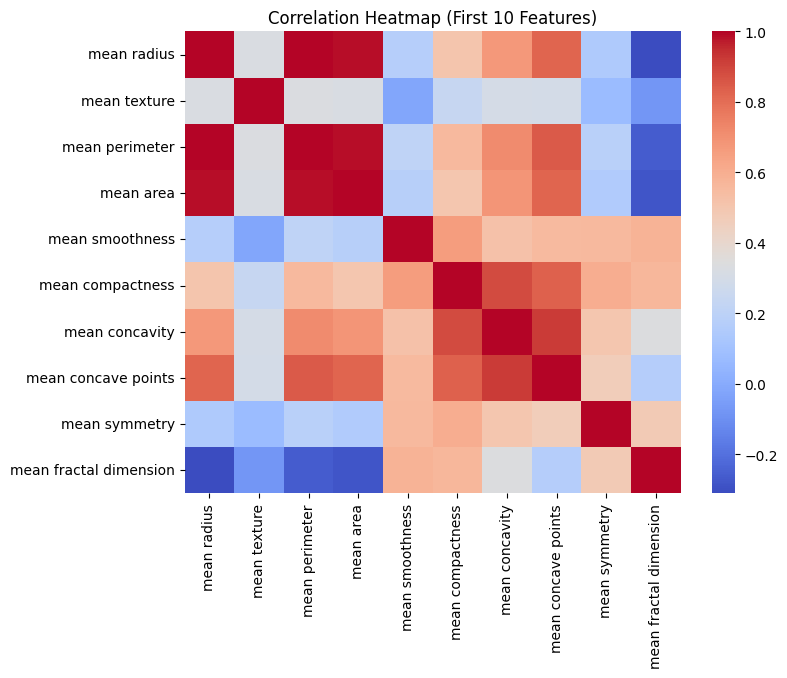

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.iloc[:, :10].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap (First 10 Features)")

plt.show()

---

# Class Distribution

In [7]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

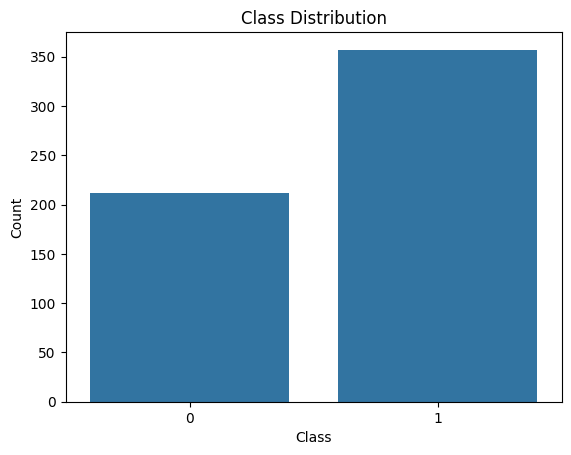

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

The class distribution shows the number of malignant and benign samples in the dataset.

The dataset is relatively balanced, which is beneficial for training classification models such as Support Vector Machines.

The dataset contains two classes:

- 0 → malignant
- 1 → benign

---

# Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---

# Feature Scaling

Support Vector Machines are sensitive to feature scale. Therefore we normalize the features using **StandardScaler**.

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---

# Final Dataset Shapes

In [11]:
print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (455, 30)
Test samples: (114, 30)


The dataset is now prepared for training the sparse SVM model.